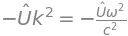

In [3]:
import sympy as sp
sp.init_printing()

# Symbols
x, y, z, t = sp.symbols("x y z t", real=True)
omega, k, c = sp.symbols("omega k c", positive=True, real=True)
mu, eps, rho = sp.symbols("mu epsilon rho", positive=True, real=True)
I = sp.I

# Phasor convention:
# physical field = Re{ F_hat * exp(j(omega*t - k*z)) }
phasor = sp.exp(I*(omega*t - k*z))

# Scalar wave field
U = sp.Function("U")
U_hat = sp.symbols(r"\hat{U}")

u = U_hat * phasor

# Wave equation: ∂²u/∂z² = (1/c²) ∂²u/∂t²
lhs_wave = sp.diff(u, z, 2)
rhs_wave = (1/c**2) * sp.diff(u, t, 2)

wave_eq_time = sp.Eq(lhs_wave, rhs_wave)
wave_eq_phasor = sp.Eq(sp.simplify(lhs_wave / phasor), sp.simplify(rhs_wave / phasor))

wave_eq_phasor

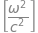

In [4]:
dispersion = sp.solve(sp.Eq(-k**2*U_hat, -(omega**2/c**2)*U_hat), k**2)
dispersion

In [5]:
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)

Ex, Ey, Ez = sp.symbols(r"\hat{E}_x \hat{E}_y \hat{E}_z")
Bx, By, Bz = sp.symbols(r"\hat{B}_x \hat{B}_y \hat{B}_z")
Jx, Jy, Jz = sp.symbols(r"\hat{J}_x \hat{J}_y \hat{J}_z")

kvec = sp.Matrix([kx, ky, kz])
E = sp.Matrix([Ex, Ey, Ez])
B = sp.Matrix([Bx, By, Bz])
J = sp.Matrix([Jx, Jy, Jz])

def cross(a, b):
    return sp.Matrix([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0]
    ])

# Frequency-domain Maxwell equations
gauss_E = sp.Eq(-I * kvec.dot(E), rho/eps)
gauss_B = sp.Eq(-I * kvec.dot(B), 0)

faraday = sp.Eq(-I * cross(kvec, E), -I * omega * B)

ampere = sp.Eq(-I * cross(kvec, B), mu*J + I*omega*mu*eps*E)

gauss_E, gauss_B, faraday, ampere

⎛                                                                              ↪
⎜                                                   ρ                          ↪
⎜-ⅈ⋅(\hat{E}ₓ⋅kₓ + \hat{E}_y⋅k_y + \hat{E}_z⋅k_z) = ─, -ⅈ⋅(\hat{B}ₓ⋅kₓ + \hat{ ↪
⎜                                                   ε                          ↪
⎝                                                                              ↪

↪                                ⎡-ⅈ⋅(-\hat{E}_y⋅k_z + \hat{E}_z⋅k_y)⎤   ⎡-ⅈ⋅\ ↪
↪                                ⎢                                   ⎥   ⎢     ↪
↪ B}_y⋅k_y + \hat{B}_z⋅k_z) = 0, ⎢ -ⅈ⋅(\hat{E}ₓ⋅k_z - \hat{E}_z⋅kₓ)  ⎥ = ⎢-ⅈ⋅\ ↪
↪                                ⎢                                   ⎥   ⎢     ↪
↪                                ⎣ -ⅈ⋅(-\hat{E}ₓ⋅k_y + \hat{E}_y⋅kₓ) ⎦   ⎣-ⅈ⋅\ ↪

↪ hat{B}ₓ⋅ω ⎤  ⎡-ⅈ⋅(-\hat{B}_y⋅k_z + \hat{B}_z⋅k_y)⎤   ⎡ ⅈ⋅\hat{E}ₓ⋅ε⋅μ⋅ω + \h ↪
↪           ⎥  ⎢                                   ⎥   ⎢                       ↪
↪ hat{B}_y⋅ω⎥, ⎢ -ⅈ⋅(\hat{

In [6]:
import sympy as sp
from IPython.display import display, Math

sp.init_printing(use_latex="mathjax")

maxwell_algebraic = {
    "Gauss E": sp.Eq(kvec.dot(E), I*rho/eps),
    "Gauss B": sp.Eq(kvec.dot(B), 0),
    "Faraday": sp.Eq(cross(kvec, E), omega*B),
    "Ampere-Maxwell": sp.Eq(cross(kvec, B), I*mu*J - omega*mu*eps*E),
}

maxwell_algebraic

for name, eq in maxwell_algebraic.items():
    display(Math(r"\textbf{" + name + r"}"))

    if isinstance(eq.lhs, sp.Matrix):
        for i in range(eq.lhs.rows):
            display(Math(sp.latex(sp.Eq(eq.lhs[i], eq.rhs[i]))))
    else:
        display(Math(sp.latex(eq)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>